In [1]:
from google.colab import files
uploaded=files.upload()

Saving test.csv to test.csv
Saving train (1).csv to train (1).csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
train_data= pd.read_csv("train (1).csv")
train_df=pd.DataFrame(train_data)
train_df.head(10)

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,...,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,...,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,...,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,...,2,1,1,0,0,0,0,0,0,0
5,2006,Croatia,Europe,0,72,45,22,10,14,0,...,2,1,1,1,1,0,0,0,0,0
6,2006,Czech Republic,Europe,0,113,37,33,7,5,0,...,0,0,0,0,0,0,0,0,0,0
7,2006,Ecuador,South America,0,59,73,17,22,12,0,...,1,0,0,0,0,0,0,0,0,0
8,2006,England,Europe,0,83,42,27,7,8,1,...,11,9,4,7,2,1,0,0,0,1
9,2006,France,Europe,0,100,23,33,3,13,1,...,11,6,4,5,4,1,0,1,1,1


In [3]:
test_data= pd.read_csv("test.csv")
test_df=pd.DataFrame(test_data)
test_df.head(10)

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,...,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,...,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,...,18,15,10,10,6,6,NaN,NaN,NaN,NaN
3,2026,England,Europe,0,82,23,26,6,7,1,...,16,13,8,10,3,1,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,...,8,5,4,3,2,0,NaN,NaN,NaN,NaN
5,2026,Brazil,South America,0,58,39,15,10,10,5,...,22,20,12,17,11,6,NaN,NaN,NaN,NaN
6,2026,Netherlands,Europe,0,92,41,21,8,9,0,...,11,11,9,7,5,3,NaN,NaN,NaN,NaN
7,2026,Morocco,Africa,0,100,18,37,2,9,0,...,6,2,2,1,1,0,NaN,NaN,NaN,NaN
8,2026,Belgium,Europe,0,80,32,19,7,10,0,...,14,9,8,3,2,0,NaN,NaN,NaN,NaN
9,2026,Germany,Europe,0,80,47,21,10,7,4,...,20,18,10,16,13,8,NaN,NaN,NaN,NaN


In [4]:
print(test_df.info(),train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          48 non-null     int64  
 1   team                             48 non-null     object 
 2   continent                        48 non-null     object 
 3   is_host                          48 non-null     int64  
 4   goals_scored_last_4y             48 non-null     int64  
 5   goals_received_last_4y           48 non-null     int64  
 6   wins_last_4y                     48 non-null     int64  
 7   losses_last_4y                   48 non-null     int64  
 8   draws_last_4y                    48 non-null     int64  
 9   world_cup_titles_before          48 non-null     int64  
 10  squad_total_market_value_eur     48 non-null     int64  
 11  fifa_rank_pre_tournament         48 non-null     int64  
 12  fifa_points_pre_tourname

In [5]:
train_df.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

In [287]:
feature_cols=['is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'semi_finalist',
       'quarter_finalist']

In [288]:
unique_years=train_df["version"].unique()
print(unique_years)

[2006 2018 2022 2010 2014 2002]


In [301]:
rf_correct = 0
xgb_correct = 0

In [289]:
for test_year in unique_years:
  train_split=train_df[train_df['version']!=test_year].copy()
  val_split=train_df[train_df['version']==test_year].copy()

In [290]:
market_value_median=train_split['squad_total_market_value_eur'].median()
train_split['squad_total_market_val_eur']=train_split['squad_total_market_value_eur'].fillna(market_value_median)
val_split['squad_total_market_val_eur']=val_split['squad_total_market_value_eur'].fillna(market_value_median)



In [291]:
train_split['squad_total_market_val_eur']=np.log1p(train_split['squad_total_market_val_eur'])
val_split['squad_total_market_val_eur']=np.log1p(val_split['squad_total_market_val_eur'])

In [292]:
x_train=train_split[feature_cols].fillna(0)
y_train=train_split['winner']
X_val=val_split[feature_cols]


In [293]:
actual_winner_team=val_split[val_split['winner']==1].iloc[0]['team']

In [294]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(max_depth= 3, max_features='sqrt', min_samples_leaf= 1, min_samples_split=2, n_estimators =50,random_state=42)

In [295]:
rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=3, n_estimators=50, random_state=42)

In [296]:
val_split['rf_prob']=rf.predict_proba(X_val)[:,1]
rf_favourite=val_split.sort_values(by="rf_prob",ascending=False).iloc[0]['team']

In [297]:
from xgboost import XGBClassifier
xgb=XGBClassifier(colsample_bytree= 0.7, gamma= 0, learning_rate= 0.01, max_depth=5, n_estimators= 50, subsample= 0.7,random_state=42)

In [298]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [299]:
val_split['xgb_prob']=xgb.predict_proba(X_val)[:,1]
xgb_favourite=val_split.sort_values(by="xgb_prob",ascending=False).iloc[0]['team']

In [300]:
rf_status="favourite" if actual_winner_team==rf_favourite else "not favourite"
xgb_status="favourite" if actual_winner_team==xgb_favourite else "not favourite"

In [302]:
if rf_favourite==actual_winner_team:
    rf_correct+=1
if xgb_favourite==actual_winner_team:
    xgb_correct+=1

In [303]:
rf_accuracy=(rf_correct/len(unique_years))*100
xgb_accuracy=(xgb_correct/len(unique_years))*100
print(f"Random Forest Accuracy: {rf_accuracy}")
print(f"XGBoost Accuracy: {xgb_accuracy}")

Random Forest Accuracy: 0.0
XGBoost Accuracy: 16.666666666666664


In [276]:
final_market_value_median=train_df['squad_total_market_value_eur'].median()
test_df['squad_total_market_val_eur']=test_df['squad_total_market_value_eur'].fillna(final_market_value_median)
train_df['squad_total_market_val_eur']=train_df['squad_total_market_value_eur'].fillna(final_market_value_median)

In [277]:
test_df['squad_total_market_val_eur']=np.log1p(test_df['squad_total_market_val_eur'])
train_df['squad_total_market_val_eur']=np.log1p(train_df['squad_total_market_val_eur'])

In [278]:
x_final_train=train_df[feature_cols].fillna(0)
y_final_train=train_df['winner']
X_2026=test_df[feature_cols].fillna(0)

In [279]:
if xgb_accuracy>=rf_accuracy:
  print("XGBOOST is the best model")
  best_model=XGBClassifier(colsample_bytree =  0.7, gamma= 0, learning_rate= 0.01, max_depth = 3, n_estimators= 50, subsample=0.7,random_state=42)
else:
  print("Random Forest is the best model")
  best_model=RandomForestClassifier( max_depth= 5, max_features='sqrt', min_samples_leaf= 1, min_samples_split=2, n_estimators =50,random_state=42)

XGBOOST is the best model


In [280]:
best_model.fit(x_final_train,y_final_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [281]:
model_probability=best_model.predict_proba(X_2026)[:,1]

In [282]:
leaderBoard=pd.DataFrame({
    'Country':test_df['team'],
    'Probability':model_probability
})


In [283]:
leaderBoard['Win_Probabiliy_percentage']=(leaderBoard['Probability']/leaderBoard['Probability'].sum())*100
leaderBoard=leaderBoard.sort_values(by='Win_Probabiliy_percentage',ascending=False).reset_index(drop=True)

In [305]:
print("\n Final 2026 FIFA WC Prediction Leaderboard ")
print(leaderBoard[['Country' , 'Win_Probabiliy_percentage']].head(5).to_string(index=False))


 Final 2026 FIFA WC Prediction Leaderboard 
  Country  Win_Probabiliy_percentage
   France                   2.980451
    Spain                   2.938393
Argentina                   2.938393
  England                   2.938393
   Brazil                   2.852642


In [285]:
from sklearn.model_selection import GridSearchCV

In [250]:
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize RandomForestClassifier
rf_tuned = RandomForestClassifier(random_state=42)

# Setup GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid_rf,
    cv=5,      # 5-fold cross-validation
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Fit GridSearchCV to the data
grid_search_rf.fit(x_final_train, y_final_train)

print("Best parameters for Random Forest:", grid_search_rf.best_params_)
print("Best cross-validation score for Random Forest:", grid_search_rf.best_score_)

best_rf_model_tuned = grid_search_rf.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


KeyboardInterrupt: 

In [135]:
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
}

# Initialize XGBClassifier
xgb_tuned = XGBClassifier(objective='binary:logistic', random_state=42)

# Setup GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid_xgb,
    cv=5,      # 5-fold cross-validation
    verbose=1,
    n_jobs=-1  # Use all available cores
)

# Fit GridSearchCV to the data
grid_search_xgb.fit(x_final_train, y_final_train)

print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best cross-validation score for XGBoost:", grid_search_xgb.best_score_)

best_xgb_model_tuned = grid_search_xgb.best_estimator_

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Best parameters for XGBoost: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.7}
Best cross-validation score for XGBoost: 0.9688259109311741


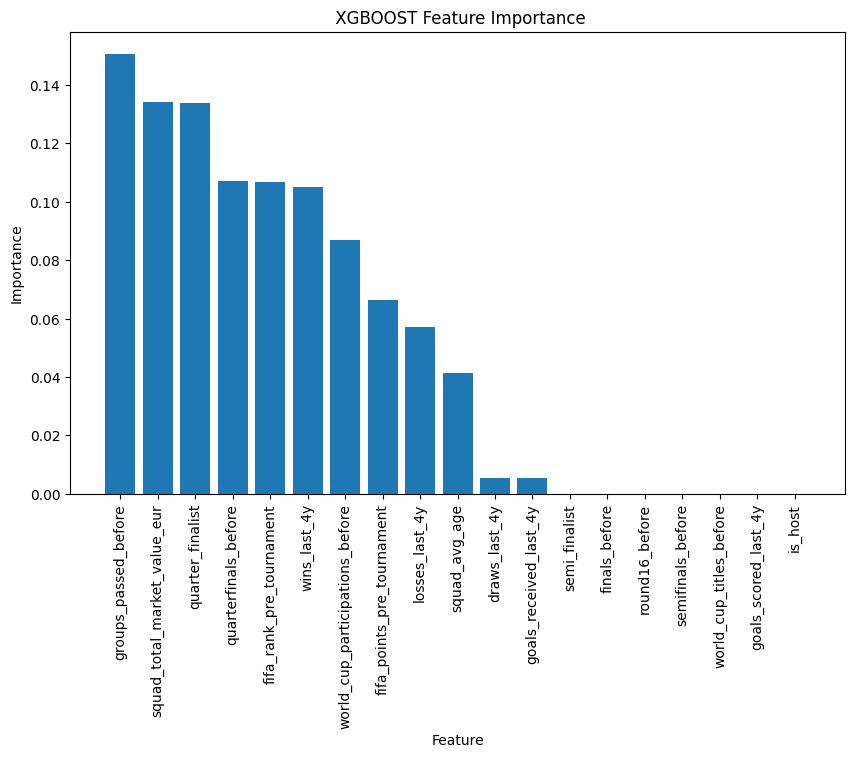

In [286]:
feature_importance=best_model.feature_importances_
feature_names=x_final_train.columns
sorted_indices=np.argsort(feature_importance)[::-1]
plt.figure(figsize=(10,6))
plt.bar(range(len(feature_importance)),feature_importance[sorted_indices],align='center')
plt.xticks(range(len(feature_importance)),np.array(feature_names)[sorted_indices],rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title(' XGBOOST Feature Importance')
plt.show()

### Model Prediction Visualization

Let's visualize the `Win_Probabiliy_percentage` for each country based on the model's predictions.

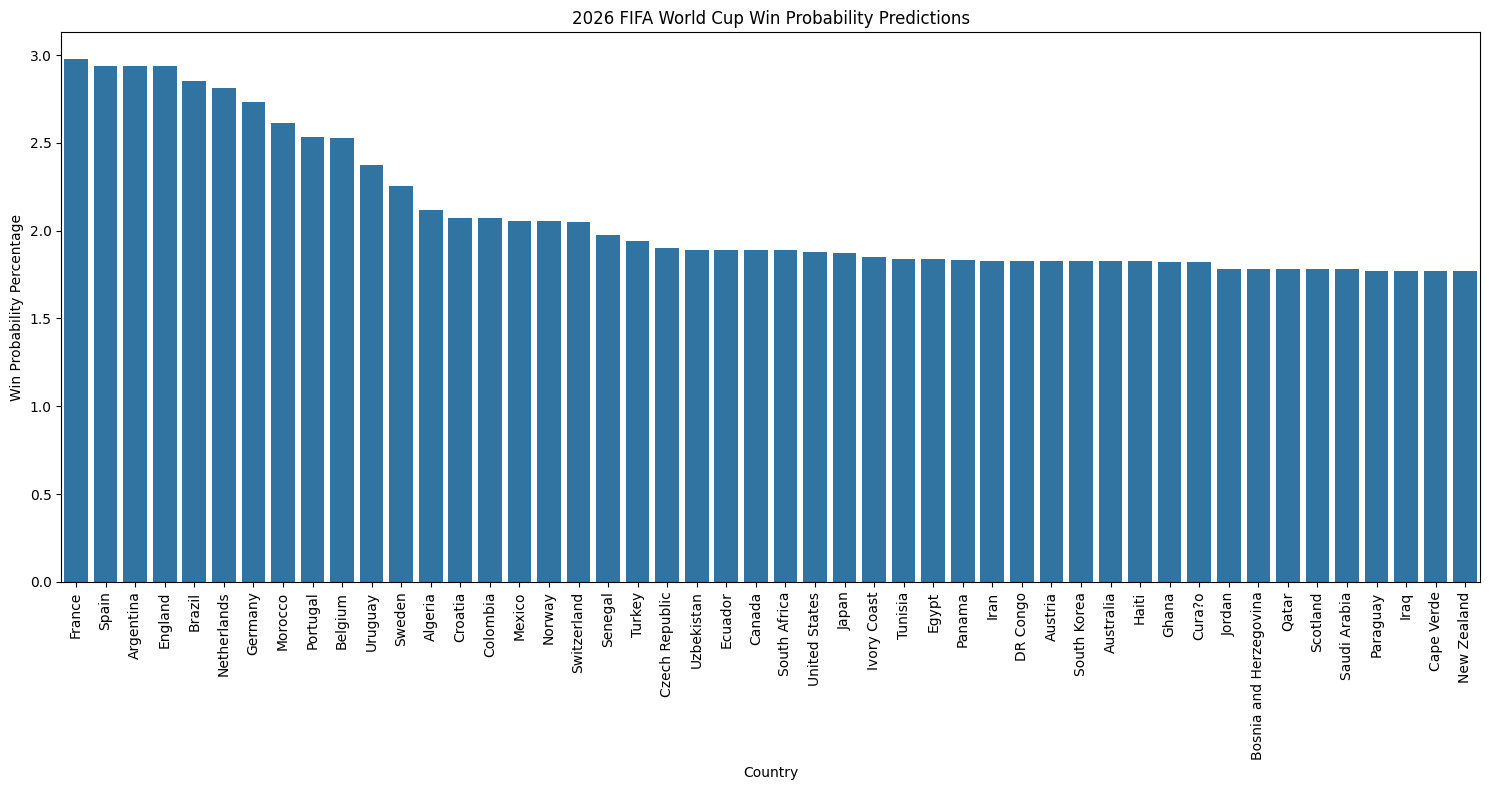

In [304]:

plt.figure(figsize=(15, 8))
sns.barplot(x='Country', y='Win_Probabiliy_percentage', data=leaderBoard.sort_values(by='Win_Probabiliy_percentage', ascending=False))
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('Win Probability Percentage')
plt.title('2026 FIFA World Cup Win Probability Predictions')
plt.tight_layout()
plt.show()

### Top 5 Countries - Predicted Win Probability (Horizontal Bar Plot)

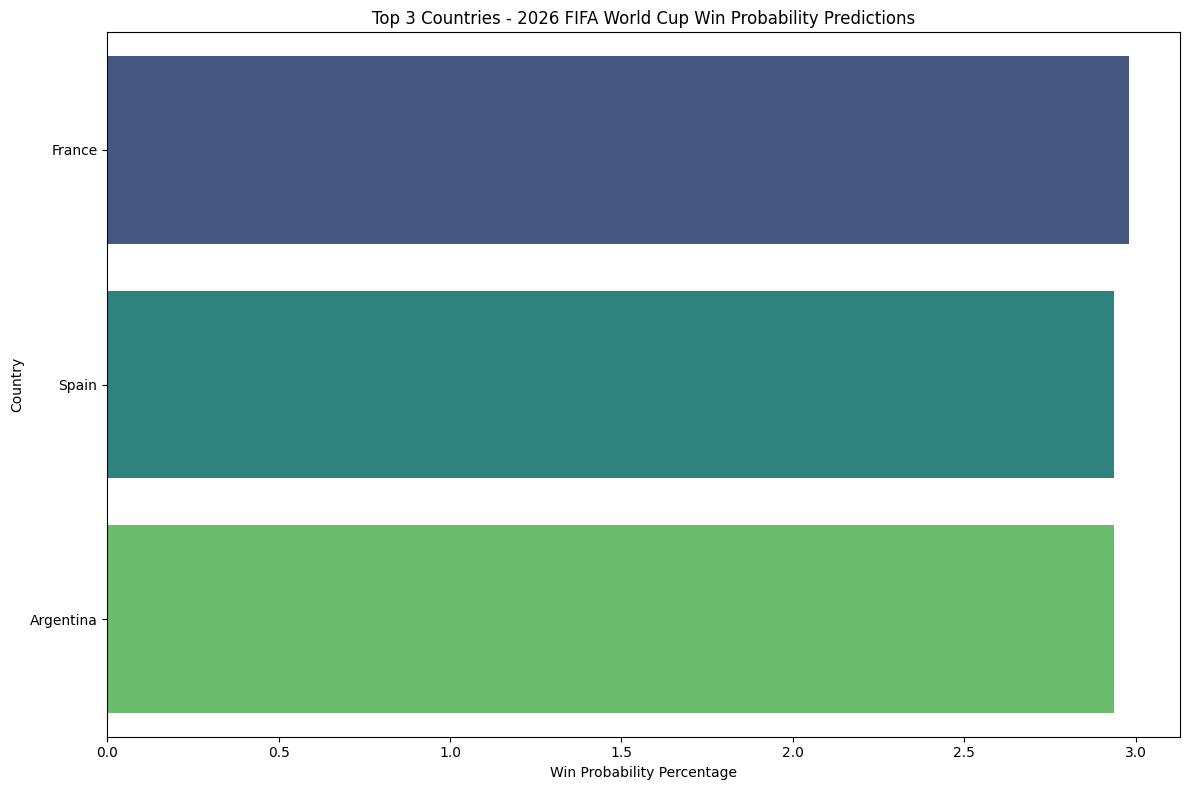

In [310]:
top_3_countries = leaderBoard.sort_values(by='Win_Probabiliy_percentage', ascending=False).head(3)

plt.figure(figsize=(12, 8))
sns.barplot(x='Win_Probabiliy_percentage', y='Country', data=top_3_countries, palette='viridis', hue='Country', legend=False)
plt.xlabel('Win Probability Percentage')
plt.ylabel('Country')
plt.title('Top 3 Countries - 2026 FIFA World Cup Win Probability Predictions')
plt.tight_layout()
plt.show()